[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/storopoli/ciencia-de-dados/main?filepath=notebooks%2FAula_19_Redes_Neurais_Convolucionais_com_PyTorch.ipynb)
<br>
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/storopoli/ciencia-de-dados/blob/main/notebooks/Aula_19_Redes_Neurais_Convolucionais_com_PyTorch.ipynb)

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/MNIST.png?raw=1" alt="MNIST" style="width: 500px;"/>

O pacote `torchvision` do `PyTorch` tem integrado já o dataset MNIST:

In [1]:
import torchvision
from torchvision import transforms

# MNIST dataset
root_path = '/home/storopoli/Downloads' # mude isso no Colab se necessário

# Pequena transformação para tensores e normalizando o tamanho
trans = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

# Train/Test Datasets
train_dataset = torchvision.datasets.MNIST(root=root_path, train=True, transform=trans, download=True)
test_dataset = torchvision.datasets.MNIST(root=root_path, train=False, transform=trans)

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


In [2]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: /home/storopoli/Downloads
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [3]:
test_dataset

Dataset MNIST
    Number of datapoints: 10000
    Root location: /home/storopoli/Downloads
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [4]:
from torch.utils.data import DataLoader

batch_size=32

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
import torch.nn as nn

In [6]:
ResNet18 = torchvision.models.resnet18()
ResNet18.fc = nn.Linear(512, 10) # modificar a camada final para 10 features

In [7]:
model = ResNet18
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [8]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(model)

11181642

In [9]:
from torch.optim import Adam

# Hiperparâmetros
loss_fn = nn.CrossEntropyLoss()
learning_rate = 0.001
epochs = 6

# Instânciar o Otimizador Adam
optimizer = Adam(model.parameters(), lr=learning_rate)

In [10]:
# Isto tem que retornar True
import torch
torch.cuda.is_available()

True

In [11]:
# Sua GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [12]:
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [13]:
total_step = len(train_loader)
total_step

1875

In [ ]:
# Treinar o Modelo
total_step = len(train_loader)

metricas = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# Treinar o Modelo
for epoch in range(epochs):
    model.train() # Coloca o modelo em modo treinamento
    running_loss = 0.0
    running_corrects = 0

    for i, (images, labels) in enumerate(train_loader):
        # Preparação dos dados
        images = images.repeat(1, 3, 1, 1).to(device)
        labels = labels.to(device)

        # Passo de otimização
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        # Acumulando dados para a média da época
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        running_corrects += torch.sum(predicted == labels.data)

        # MOSTRA O PROGRESSO
        if (i + 1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], "
                  f"Loss: {loss.item():.4f}")

    # CALCULA A MÉDIA DA ÉPOCA
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    # Guarda um valor por época (ambos convertidos para float)
    metricas['train_loss'].append(epoch_loss)
    metricas['train_acc'].append(epoch_acc.item())

    print(f">>> Final da Época {epoch+1}: Loss Média: {epoch_loss:.4f}, Acc Média: {epoch_acc:.4f}")

    # --- Validação ---
    model.eval()
    val_loss_cum = 0.0
    val_corrects = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.repeat(1, 3, 1, 1).to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            val_loss_cum += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_corrects += torch.sum(predicted == labels.data)

    # Salva métricas de validação (convertidas para float também)
    metricas['val_loss'].append(val_loss_cum / len(test_dataset))
    metricas['val_acc'].append((val_corrects.double() / len(test_dataset)).item())

Época [1/6], Step [100/1875], Loss: 0.0027
Época [1/6], Step [200/1875], Loss: 0.0004
Época [1/6], Step [300/1875], Loss: 0.0064
Época [1/6], Step [400/1875], Loss: 0.0007
Época [1/6], Step [500/1875], Loss: 0.0001
Época [1/6], Step [600/1875], Loss: 0.0035
Época [1/6], Step [700/1875], Loss: 0.0045
Época [1/6], Step [800/1875], Loss: 0.0001
Época [1/6], Step [900/1875], Loss: 0.0009
Época [1/6], Step [1000/1875], Loss: 0.0011
Época [1/6], Step [1100/1875], Loss: 0.0010
Época [1/6], Step [1200/1875], Loss: 0.3437
Época [1/6], Step [1300/1875], Loss: 0.0010
Época [1/6], Step [1400/1875], Loss: 0.0034
Época [1/6], Step [1500/1875], Loss: 0.0008
Época [1/6], Step [1600/1875], Loss: 0.0001
Época [1/6], Step [1700/1875], Loss: 0.0001
Época [1/6], Step [1800/1875], Loss: 0.0031
>>> Final da Época 1: Loss Média: 0.0141, Acc Média: 0.9958
Época [2/6], Step [100/1875], Loss: 0.0071
Época [2/6], Step [200/1875], Loss: 0.0072
Época [2/6], Step [300/1875], Loss: 0.0005
Época [2/6], Step [400/1875]

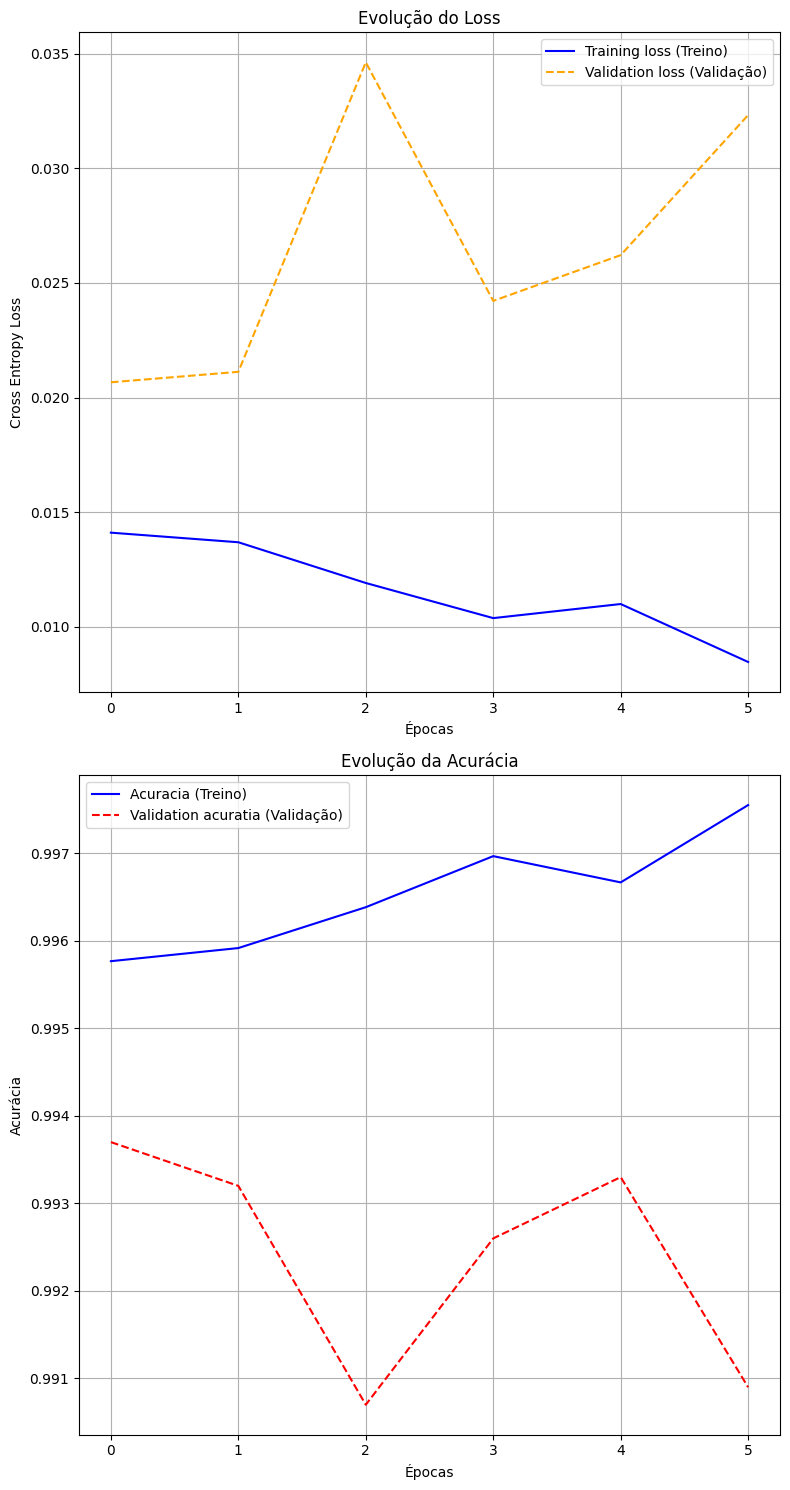

In [32]:
import matplotlib.pyplot as plt

fig, (ax1, ay1) = plt.subplots(2, 1, figsize=(8, 15))

ax1.plot(metricas['train_loss'], label=f'Training loss (Treino)', color='blue', linestyle='-')
ax1.plot(metricas['val_loss'], label=f'Validation loss (Validação)', color='orange', linestyle='--')

ax1.set_title("Evolução do Loss")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Cross Entropy Loss")
ax1.legend()
ax1.grid(True)

ay1.plot(metricas['train_acc'], label=f'Acuracia (Treino)', color='blue', linestyle='-')

ay1.plot([acc.cpu().item() for acc in metricas['val_acc']], label=f'Validation acuratia (Validação)', color='red', linestyle='--')

ay1.set_title("Evolução da Acurácia")
ay1.set_xlabel("Épocas")
ay1.set_ylabel("Acurácia")
ay1.legend()
ay1.grid(True)

plt.tight_layout()
plt.show()